In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
import os

os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["PYTHONHASHSEED"] = "0"

# 2. Set non-TensorFlow seeds
import random
import numpy as np

random.seed(42)
np.random.seed(42)

# 3. Import TensorFlow and set its seed last
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten

tf.random.set_seed(42)
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

### DataSet

In [2]:
X, y = make_moons(100, noise=0.25,random_state=2) 

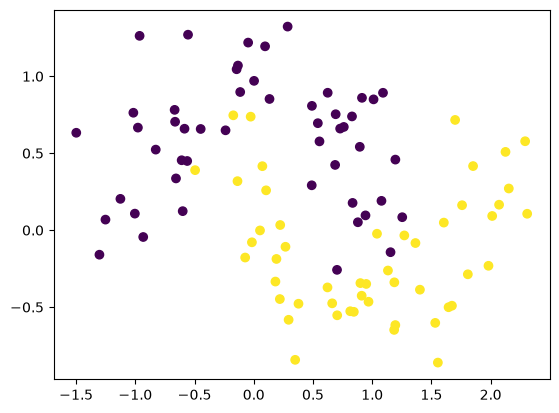

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

### Without Zero Initialization

In [4]:
model=Sequential([
    Dense(units=128 , activation='relu' , input_dim=2), 
    Dense(units=1 , activation="sigmoid")
])

C:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.get_weights()

[array([[ 1.53902724e-01,  6.98764175e-02, -6.07075989e-02,
          1.93346545e-01, -1.81294039e-01,  6.54524714e-02,
          2.02159181e-01, -1.42687842e-01,  1.02215111e-02,
          5.61833233e-02, -1.77703217e-01, -2.30485201e-02,
          2.00240210e-01, -1.27435178e-02,  1.26597285e-03,
          1.14148423e-01, -2.06743822e-01, -1.32174373e-01,
          6.11916184e-03, -1.86293826e-01, -1.98659584e-01,
          1.49510428e-01,  1.78496465e-01, -1.02028832e-01,
          1.54479668e-01, -1.60062611e-01, -1.62047893e-02,
          2.69496292e-02,  2.86554247e-02, -1.28831059e-01,
         -1.24736018e-01,  2.10178509e-01, -1.67616874e-01,
         -2.42276192e-02, -1.00934148e-01, -1.62835389e-01,
          1.00174293e-01, -1.36488363e-01,  7.78971463e-02,
          6.46303743e-02, -1.96517333e-01,  2.73423344e-02,
         -7.12727457e-02, -4.86184210e-02,  1.95293739e-01,
         -3.85008901e-02,  1.35217607e-02, -1.05131514e-01,
         -1.62063748e-01,  9.27354246e-0

In [7]:
len(model.get_weights())

4

In [8]:
initial_weights = model.get_weights()

In [9]:
initial_weights[0] = np.ones(model.get_weights()[0].shape)*0.5
initial_weights[1] = np.ones(model.get_weights()[1].shape)*0.5
initial_weights[2] = np.ones(model.get_weights()[2].shape)*0.5
initial_weights[3] = np.ones(model.get_weights()[3].shape)*0.5

In [10]:
model.set_weights(initial_weights)

In [11]:
model.get_weights()

[array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
         0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
         0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
         0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
         0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
         0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
         0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
         0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
         0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
         0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
         0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
         0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
         0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5

In [12]:
adam = Adam(learning_rate=0.01)
model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history1 = model.fit(X, y, epochs=50, validation_split = 0.2,verbose=1)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.5375 - loss: 25.4048 - val_accuracy: 0.3500 - val_loss: 23.6927
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5375 - loss: 22.4518 - val_accuracy: 0.3500 - val_loss: 20.8279
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5375 - loss: 19.7047 - val_accuracy: 0.3500 - val_loss: 18.1699
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5375 - loss: 17.1602 - val_accuracy: 0.3500 - val_loss: 15.7238
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5375 - loss: 14.8223 - val_accuracy: 0.3500 - val_loss: 13.4936
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5375 - loss: 12.6926 - val_accuracy: 0.3500 - val_loss: 11.4783
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5375 - loss: 10.7700 - val_accuracy: 0.3500 - val_loss: 9.6731
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5375 - loss: 9.0510 - val_accuracy: 0.3500 - val

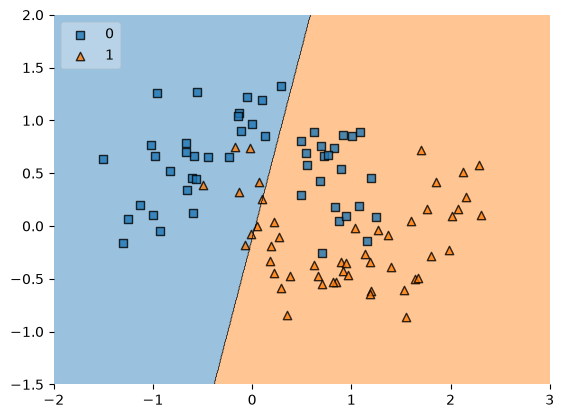

In [13]:
class KerasClassifierWrapper:
    def __init__(self, model):
        self.model = model
    def predict(self, X):
        preds = self.model.predict(X, verbose=0)
        return (preds > 0.5).astype(int).ravel()  # flatten to 1D int labels

wrapped_model = KerasClassifierWrapper(model)
plot_decision_regions(X, y.astype(int), clf=wrapped_model, legend=2)
plt.xlim(-2, 3)
plt.ylim(-1.5, 2)
plt.show()

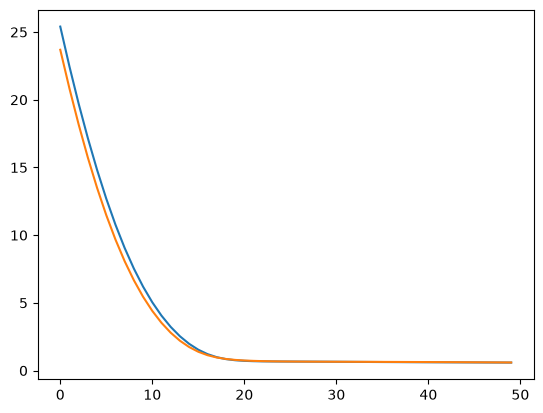

In [14]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

In [15]:
model.get_weighs()

AttributeError: 'Sequential' object has no attribute 'get_weighs'